# Analisis Exploratorio de Calidad del Aire (PM2.5) en Medellin

> Dataset objetivo: **PM2.5 Medellin Air Quality August 2018 to September 2019**

Este notebook fue preparado para una actividad academica de analisis exploratorio basico (EDA) con Python.

## 1. Preparacion del entorno

Usaremos estas librerias:
- **pandas**: manejo y analisis de datos tabulares.
- **numpy**: operaciones numericas y soporte para arreglos.
- **matplotlib**: graficas base en Python.
- **seaborn**: visualizaciones estadisticas con mejor estilo.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configuracion visual basica para graficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerias importadas correctamente.')
print('Version de numpy:', np.__version__)

Librerias importadas correctamente.
Version de numpy: 2.4.4


In [3]:
# Carga del JSON objetivo para analisis de PM2.5
json_candidates = [
    Path('data/datos_siata_aire_pm25.json'),
    Path('data/Datos_SIATA_Aire_pm25.json'),
    Path('notebooks/data/datos_siata_aire_pm25.json'),
    Path('notebooks/data/Datos_SIATA_Aire_pm25.json'),
]

json_path = next((p for p in json_candidates if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('No se encontro datos_siata_aire_pm25.json en rutas esperadas.')

print(f'Archivo JSON encontrado: {json_path}')

with open(json_path, 'r', encoding='utf-8') as f:
    estaciones = json.load(f)

# Aplanamos la estructura anidada para tener un DataFrame tabular
rows = []
for estacion in estaciones:
    nombre_estacion = estacion.get('nombre')
    codigo_serial = estacion.get('codigoSerial')
    for registro in estacion.get('datos', []):
        rows.append({
            'estacion': nombre_estacion,
            'codigoSerial': codigo_serial,
            'variableConsulta': registro.get('variableConsulta'),
            'fecha': registro.get('fecha'),
            'calidad': registro.get('calidad'),
            'pm25': registro.get('valor')
        })

df = pd.DataFrame(rows)
print(f'DataFrame PM2.5 creado con {df.shape[0]} filas y {df.shape[1]} columnas.')
df.head()

Archivo JSON encontrado: data\datos_siata_aire_pm25.json
DataFrame PM2.5 creado con 183981 filas y 6 columnas.


,estacion,codigoSerial,variableConsulta,fecha,calidad,pm25
0,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 04:00:00,1.0,15.0
1,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 05:00:00,1.0,20.0
2,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 06:00:00,1.0,29.0
3,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 07:00:00,1.0,22.0
4,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 08:00:00,1.0,29.0


## 3. Inspeccion rapida

Revisamos las primeras y ultimas filas, y tambien el tamano del DataFrame para tener una primera impresion de los datos.

In [4]:
print('Primeras 5 filas:')
display(df.head())

print('Ultimas 5 filas:')
display(df.tail())

print('Dimensiones (filas, columnas):', df.shape)

Primeras 5 filas:


,estacion,codigoSerial,variableConsulta,fecha,calidad,pm25
0,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 04:00:00,1.0,15.0
1,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 05:00:00,1.0,20.0
2,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 06:00:00,1.0,29.0
3,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 07:00:00,1.0,22.0
4,Girardota - S.O.S Aburrá Norte,3,pm25,2018-08-28 08:00:00,1.0,29.0


Ultimas 5 filas:


,estacion,codigoSerial,variableConsulta,fecha,calidad,pm25
183976,Sabaneta - I.E. Rafael J. Mejía,90,pm25,2019-08-28 00:00:00,1.0,15.6297
183977,Sabaneta - I.E. Rafael J. Mejía,90,pm25,2019-08-28 01:00:00,1.0,18.0261
183978,Sabaneta - I.E. Rafael J. Mejía,90,pm25,2019-08-28 02:00:00,1.0,15.5873
183979,Sabaneta - I.E. Rafael J. Mejía,90,pm25,2019-08-28 03:00:00,1.0,20.3708
183980,Sabaneta - I.E. Rafael J. Mejía,90,pm25,2019-08-28 04:00:00,1.0,17.9231


Dimensiones (filas, columnas): (183981, 6)


**Primera impresion:**
- El DataFrame contiene mediciones por estacion y por hora.
- La variable principal de interes es `pm25` y la fecha viene en formato texto inicialmente.
- En la siguiente seccion revisamos tipos de datos y nulos.

## 4. Diagnostico principal con `df.info()`

Aqui verificamos tipos de datos, conteos no nulos y posibles problemas iniciales.

In [5]:
df.info()

print('\nValores nulos por columna:')
display(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 183981 entries, 0 to 183980
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   estacion          183981 non-null  str    
 1   codigoSerial      183981 non-null  int64  
 2   variableConsulta  183981 non-null  str    
 3   fecha             183981 non-null  str    
 4   calidad           183981 non-null  str    
 5   pm25              183981 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 8.4 MB

Valores nulos por columna:


estacion            0
codigoSerial        0
variableConsulta    0
fecha               0
calidad             0
pm25                0
dtype: int64

**Lectura del diagnostico:**
- Esperamos que `fecha` aparezca como texto (`object`) antes de convertirla.
- `pm25` puede venir como numero o texto, por eso luego lo convertimos a numerico.
- Si hay nulos, los trataremos en la etapa de limpieza.

## 5. Resumen estadistico

Aplicamos resumen para variables numericas y para columnas categoricas.

In [13]:
print('Resumen estadistico de variables numericas:')
display(df.describe())

print('\nResumen de variables categoricas:')
display(df.describe(include=['object', 'string']))

Resumen estadistico de variables numericas:


,codigoSerial,pm25
count,183981.000000,183981.000000
mean,61.952381,222.837957
std,27.908901,5130.772125
min,3.000000,-9999.000000
25%,38.000000,11.097500
50%,79.000000,18.000000
75%,84.000000,27.000000
max,90.000000,115035.000000



Resumen de variables categoricas:


,estacion,variableConsulta,fecha,calidad
count,183981,183981,183981,183981
unique,21,1,8761,15
top,Girardota - S.O.S Aburrá Norte,pm25,2018-08-28 04:00:00,1.0
freq,8761,183981,21,171196


**Interpretacion esperada del resumen:**
- `mean`: promedio de las mediciones de PM2.5.
- `std`: variacion o dispersion de los valores.
- `min` y `max`: extremos observados.
- En columnas categoricas, se observan frecuencias y categorias dominantes (por ejemplo, estaciones o calidad).

## 6. Limpieza basica de datos

En esta parte convertimos fecha, tratamos nulos y revisamos duplicados.

In [7]:
df_clean = df.copy()

# Aseguramos que solo trabajamos la variable PM2.5
df_clean = df_clean[df_clean['variableConsulta'].astype(str).str.lower() == 'pm25']

# Conversion de tipos
df_clean['fecha'] = pd.to_datetime(df_clean['fecha'], errors='coerce')
df_clean['pm25'] = pd.to_numeric(df_clean['pm25'], errors='coerce')

print('Nulos antes de limpiar:')
display(df_clean[['fecha', 'pm25', 'calidad']].isnull().sum())

# Tratamiento de nulos
df_clean['calidad'] = df_clean['calidad'].fillna('sin_dato')
df_clean = df_clean.dropna(subset=['fecha', 'pm25']).copy()

# Duplicados
duplicados_antes = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()
duplicados_despues = df_clean.duplicated().sum()

print('\nDuplicados antes de eliminar:', duplicados_antes)
print('Duplicados despues de eliminar:', duplicados_despues)
print('Dimension final limpia:', df_clean.shape)

Nulos antes de limpiar:


fecha      0
pm25       0
calidad    0
dtype: int64


Duplicados antes de eliminar: 0
Duplicados despues de eliminar: 0
Dimension final limpia: (183981, 6)


## 7. Analisis exploratorio basico

Generamos dos vistas simples:
1. Serie temporal de PM2.5 (promedio diario).
2. Promedio mensual de PM2.5.

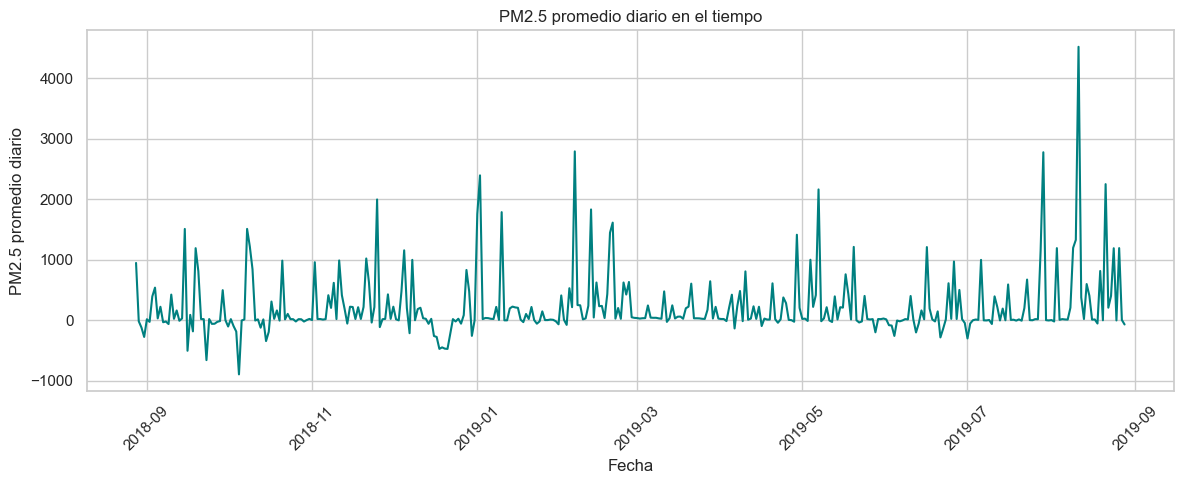

In [8]:
# Promedio diario de PM2.5
df_daily = (
    df_clean.set_index('fecha')['pm25']
    .resample('D')
    .mean()
    .reset_index()
    .rename(columns={'pm25': 'pm25_promedio_dia'})
)

plt.figure()
sns.lineplot(data=df_daily, x='fecha', y='pm25_promedio_dia', color='teal')
plt.title('PM2.5 promedio diario en el tiempo')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 promedio diario')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

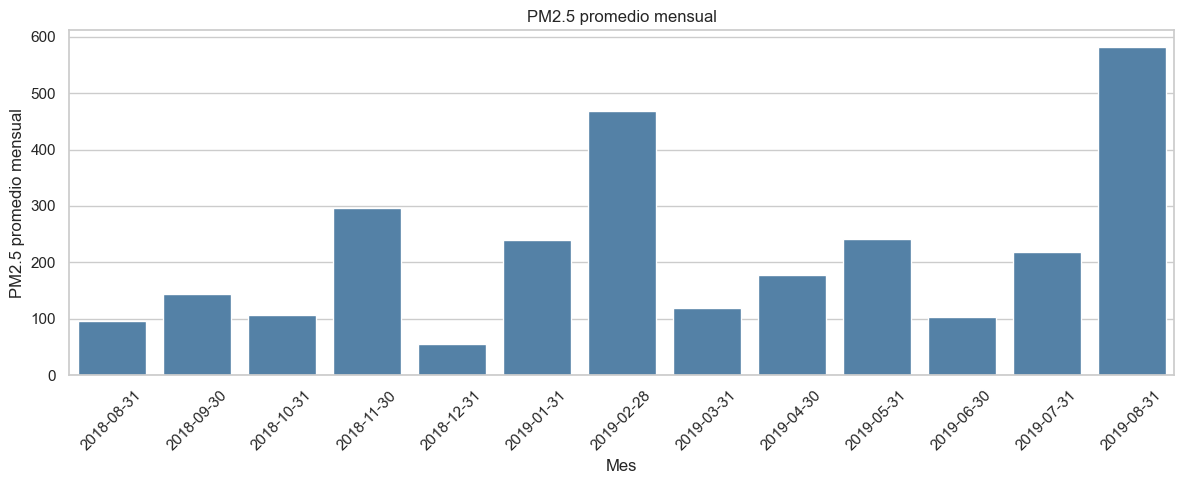

In [10]:
# Promedio mensual de PM2.5
df_monthly = (
    df_clean.set_index('fecha')['pm25']
    .resample('ME')
    .mean()
    .reset_index()
    .rename(columns={'pm25': 'pm25_promedio_mes'})
)

plt.figure()
sns.barplot(data=df_monthly, x='fecha', y='pm25_promedio_mes', color='steelblue')
plt.title('PM2.5 promedio mensual')
plt.xlabel('Mes')
plt.ylabel('PM2.5 promedio mensual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretacion simple de las graficas:**
- La serie diaria permite ver subidas y bajadas en la concentracion de PM2.5 a lo largo del periodo.
- El promedio mensual ayuda a identificar meses relativamente mas limpios o mas contaminados.
- Si ves picos marcados, pueden asociarse a condiciones meteorologicas o de movilidad urbana.

## 8. Analisis de PM2.5 segun Pico y Placa y festivos

Con base en tu calendario de referencia, construimos variables para comparar la calidad del aire entre:

- Dias laborales con Pico y Placa regular (lunes a viernes no festivo).
- Dias laborales dentro de periodos de Pico y Placa ambiental.
- Sabados con y sin restriccion ambiental.
- Lunes festivos como puntos de control (flujo vehicular reducido).

Tambien se resaltan los periodos ambientales en la serie temporal para detectar cambios atipicos.

Resumen de PM2.5 por tipo de dia y politica de movilidad:


,index,tipo_dia,count,pm25_media,pm25_mediana,pm25_std
2,2,Laboral con Pico y Placa regular,218,222.156851,19.123081,510.885839
3,3,Laboral con restriccion ambiental,29,274.984892,47.758664,403.274032
5,5,Sabado con restriccion ambiental,6,64.391381,30.235221,77.195790
6,6,Sabado sin restriccion ambiental,46,235.505721,16.868186,438.508579
4,4,Lunes festivo (control),9,127.576779,19.233110,399.429393
1,1,Festivo (no lunes),6,304.432146,15.137508,709.856590
0,0,Domingo,52,208.597702,14.332740,745.163266


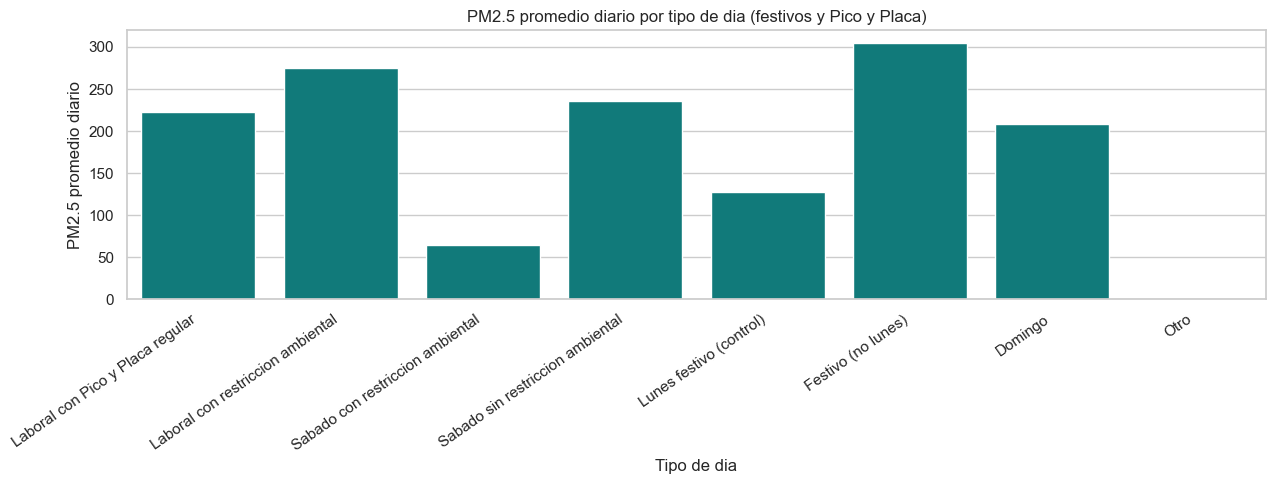

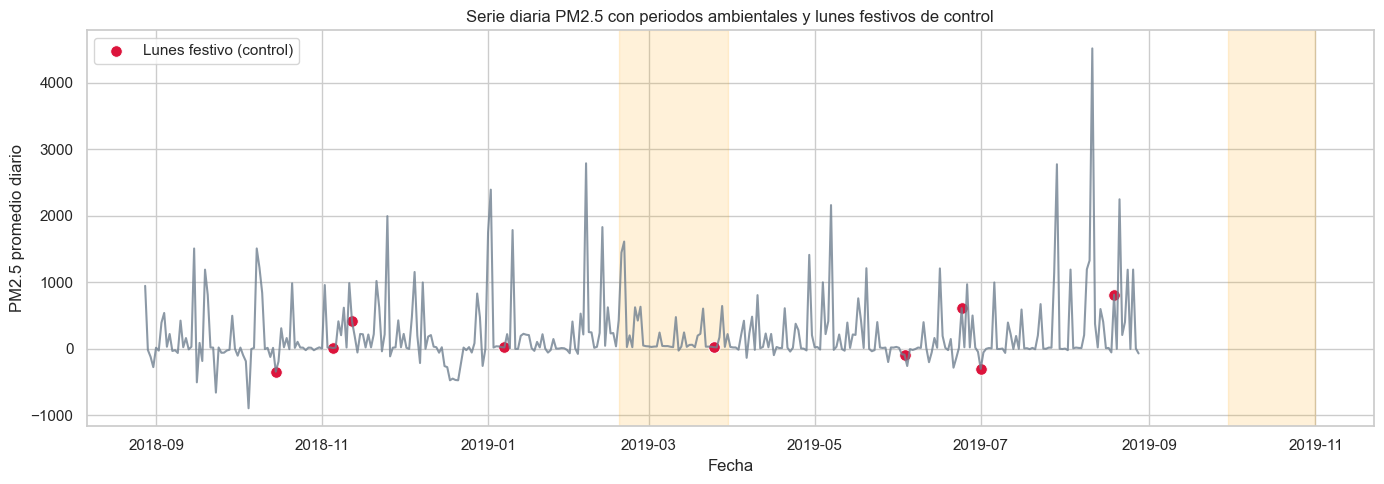


Comparaciones clave:
- Lunes festivo (control): 127.58
- Laboral con Pico y Placa regular: 222.16
- Laboral con restriccion ambiental: 274.98
- Diferencia laboral regular vs lunes festivo: 94.58
- Diferencia laboral ambiental vs laboral regular: 52.83


In [11]:
# Analisis de PM2.5 usando calendario de Pico y Placa y festivos
df_policy = df_daily.dropna(subset=['pm25_promedio_dia']).copy()
df_policy['fecha'] = pd.to_datetime(df_policy['fecha'])
df_policy['dow'] = df_policy['fecha'].dt.dayofweek  # lunes=0, domingo=6
df_policy['dia_semana'] = df_policy['fecha'].dt.day_name()

# Festivos suministrados para 2018-2019
festivos = pd.to_datetime([
    '2018-08-07', '2018-08-20',
    '2018-10-15',
    '2018-11-05', '2018-11-12',
    '2018-12-25',
    '2019-01-01', '2019-01-07',
    '2019-03-25',
    '2019-04-18', '2019-04-19',
    '2019-05-01',
    '2019-06-03', '2019-06-24',
    '2019-07-01',
    '2019-08-07', '2019-08-19',
])

df_policy['es_festivo'] = df_policy['fecha'].dt.normalize().isin(festivos)
df_policy['es_lunes_festivo'] = df_policy['es_festivo'] & (df_policy['dow'] == 0)

# Periodos de Pico y Placa ambiental (incluye sabados)
periodos_ambientales = [
    (pd.Timestamp('2019-02-18'), pd.Timestamp('2019-03-30')),
    (pd.Timestamp('2019-09-30'), pd.Timestamp('2019-11-01')),
]

df_policy['periodo_ambiental'] = False
for inicio, fin in periodos_ambientales:
    df_policy['periodo_ambiental'] |= df_policy['fecha'].between(inicio, fin)

df_policy['es_laboral'] = df_policy['dow'].between(0, 4)
df_policy['es_sabado'] = df_policy['dow'] == 5

df_policy['laboral_regular'] = (
    df_policy['es_laboral']
    & ~df_policy['es_festivo']
    & ~df_policy['periodo_ambiental']
)
df_policy['laboral_ambiental'] = (
    df_policy['es_laboral']
    & ~df_policy['es_festivo']
    & df_policy['periodo_ambiental']
)
df_policy['sabado_ambiental'] = (
    df_policy['es_sabado']
    & df_policy['periodo_ambiental']
    & ~df_policy['es_festivo']
)

condiciones = [
    df_policy['es_lunes_festivo'],
    df_policy['es_festivo'],
    df_policy['sabado_ambiental'],
    df_policy['laboral_ambiental'],
    df_policy['laboral_regular'],
    df_policy['es_sabado'],
    df_policy['dow'] == 6,
]
etiquetas = [
    'Lunes festivo (control)',
    'Festivo (no lunes)',
    'Sabado con restriccion ambiental',
    'Laboral con restriccion ambiental',
    'Laboral con Pico y Placa regular',
    'Sabado sin restriccion ambiental',
    'Domingo',
]

df_policy['tipo_dia'] = np.select(condiciones, etiquetas, default='Otro')

orden = [
    'Laboral con Pico y Placa regular',
    'Laboral con restriccion ambiental',
    'Sabado con restriccion ambiental',
    'Sabado sin restriccion ambiental',
    'Lunes festivo (control)',
    'Festivo (no lunes)',
    'Domingo',
    'Otro',
]

resumen_politica = (
    df_policy.groupby('tipo_dia', as_index=False)['pm25_promedio_dia']
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
    .rename(columns={'mean': 'pm25_media', 'median': 'pm25_mediana', 'std': 'pm25_std'})
)
resumen_politica['tipo_dia'] = pd.Categorical(resumen_politica['tipo_dia'], categories=orden, ordered=True)
resumen_politica = resumen_politica.sort_values('tipo_dia')

print('Resumen de PM2.5 por tipo de dia y politica de movilidad:')
display(resumen_politica)

plt.figure(figsize=(13, 5))
sns.barplot(data=resumen_politica, x='tipo_dia', y='pm25_media', color='darkcyan')
plt.title('PM2.5 promedio diario por tipo de dia (festivos y Pico y Placa)')
plt.xlabel('Tipo de dia')
plt.ylabel('PM2.5 promedio diario')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_policy, x='fecha', y='pm25_promedio_dia', color='slategray', alpha=0.8)
for inicio, fin in periodos_ambientales:
    plt.axvspan(inicio, fin, color='orange', alpha=0.15)

lunes_festivos = df_policy[df_policy['es_lunes_festivo']]
sns.scatterplot(
    data=lunes_festivos,
    x='fecha',
    y='pm25_promedio_dia',
    color='crimson',
    s=70,
    label='Lunes festivo (control)'
)
plt.title('Serie diaria PM2.5 con periodos ambientales y lunes festivos de control')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 promedio diario')
plt.legend()
plt.tight_layout()
plt.show()

# Comparaciones clave sugeridas
media_lunes_festivo = df_policy.loc[df_policy['es_lunes_festivo'], 'pm25_promedio_dia'].mean()
media_laboral_regular = df_policy.loc[df_policy['laboral_regular'], 'pm25_promedio_dia'].mean()
media_laboral_ambiental = df_policy.loc[df_policy['laboral_ambiental'], 'pm25_promedio_dia'].mean()

print('\nComparaciones clave:')
print(f"- Lunes festivo (control): {media_lunes_festivo:.2f}")
print(f"- Laboral con Pico y Placa regular: {media_laboral_regular:.2f}")
print(f"- Laboral con restriccion ambiental: {media_laboral_ambiental:.2f}")

if pd.notna(media_lunes_festivo) and pd.notna(media_laboral_regular):
    delta_control = media_laboral_regular - media_lunes_festivo
    print(f"- Diferencia laboral regular vs lunes festivo: {delta_control:.2f}")

if pd.notna(media_laboral_ambiental) and pd.notna(media_laboral_regular):
    delta_ambiental = media_laboral_ambiental - media_laboral_regular
    print(f"- Diferencia laboral ambiental vs laboral regular: {delta_ambiental:.2f}")

**Lectura de resultados del cruce PM2.5 vs movilidad:**

- El promedio en **lunes festivo (control)** fue menor que en **laboral regular** (127.58 vs 222.16), consistente con menor flujo vehicular.
- En **laboral con restriccion ambiental** el promedio fue mas alto que en laboral regular (274.98 vs 222.16), lo que sugiere que estas medidas suelen activarse durante episodios criticos y no necesariamente implican mejora inmediata el mismo dia.
- En los **sabados con restriccion ambiental** el promedio fue bastante menor frente a sabados sin restriccion (64.39 vs 235.51), un patron compatible con reduccion de movilidad en fines de semana intervenidos.
- La diferencia entre media y mediana en varias categorias indica alta presencia de picos extremos; por eso conviene complementar la interpretacion con mediana y analisis de outliers antes de modelar correlaciones causales.

**Recomendacion para modelado:**
Usar los lunes festivos como variable de control (dummy) es una buena estrategia para aproximar dias laborales con trafico reducido y comparar estaciones de centro/sur (Itagui/La Estrella) frente a dias laborales regulares.

## 9. Conclusiones

1. El dataset de PM2.5 muestra variaciones claras en el tiempo, por lo que es util para analizar comportamiento de la calidad del aire.
2. Al promediar por dia y por mes se observan patrones temporales que no siempre se ven en datos crudos por hora.
3. La limpieza basica (tipos, nulos, duplicados) fue clave para evitar errores y obtener graficas confiables.
4. Con el analisis por calendario (festivos y periodos ambientales) puedes contrastar dias de control y medir diferencias de PM2.5 asociadas a cambios de movilidad.